# Modelo de Ávore de Decisão — Modelagem e Classificação de Perfil de Eficiência Energética

## Contexto


As etapas de exploração de dados (EDA), análise de padrões de consumo,
tratamento de valores nulos e definição dos critérios de categorização
foram realizadas no notebook `01_dataset.ipynb`, que gerou a base
final utilizada aqui: `data/processed/energiai_dataset_v1.csv`.

## Objetivo deste notebook

- Preparar a base já tratada para o treinamento (Parte 1);
- Treinar um modelo supervisionado — Árvore de Decisão — para classificar o
  perfil energético em Eficiente, Moderado ou Ineficiente (Parte 2);
- Avaliar o modelo com métricas adequadas (Parte 3);
- Analisar a importância de cada variável na decisão do modelo (Parte 4);
- Definir a lógica de geração de recomendações personalizadas (Parte 5);
- Serializar o modelo treinado e o contexto de recomendação (Parte 6);
- Demonstrar exemplos reais de utilização do modelo (Parte 7).

## Arquitetura da solução


Os artefatos gerados aqui (`decision_tree_model.joblib` e
`recommendation_context.json`) são consumidos diretamente pelo
microsserviço em `models/arvore_decisao/`, responsável por expor a
classificação via `POST /predict`.

In [25]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
)
import joblib

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

DATA_PATH = Path("../data/processed/energiai_dataset_v1.csv")
ARTIFACTS_DIR = Path("arvore_decisao/artifacts")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

In [26]:
df = pd.read_csv(DATA_PATH)

print(f"Dimensões da base: {df.shape[0]} linhas x {df.shape[1]} colunas")
df.head()

Dimensões da base: 479 linhas x 8 colunas


,meter_id,consumo_kwh,horas_alto_consumo,uso_horario_pico,tipo_imovel,quantidade_equipamentos,categoria,custo_estimado_mensal
0,MAC000002,360.082000,7.183168,True,Casa,8,Ineficiente,270.06
1,MAC000003,441.140001,4.742568,False,Casa,16,Moderado,330.86
2,MAC000004,50.913500,5.017372,False,Apartamento,3,Eficiente,38.19
3,MAC000006,87.027500,9.070302,False,Apartamento,6,Eficiente,65.27
4,MAC000007,270.542500,6.805927,True,Apartamento,8,Ineficiente,202.91


## Parte 1 — Tratamento e transformação de variáveis (para modelagem)

A base já chega tratada do notebook de dados (sem nulos, com os tipos
corretos). Nesta etapa, o "tratamento" tem um propósito específico de
modelagem: selecionar as variáveis explicativas (`features`), a
variável-alvo (`target`), e preparar a codificação da variável categórica
`tipo_imovel` — que será tratada com One-Hot Encoding dentro do próprio
pipeline do scikit-learn.

Encapsular essa transformação dentro do `Pipeline` garante que a mesma
lógica de codificação usada no treino seja aplicada de forma idêntica em
produção (no microsserviço), evitando divergência entre os dois ambientes.

In [27]:
FEATURES = [
    "consumo_kwh",
    "horas_alto_consumo",
    "uso_horario_pico",
    "tipo_imovel",
    "quantidade_equipamentos",
]
TARGET = "categoria"

# normalização defensiva: mesmo padrão de maiúsculas usado pela API
# (evita o bug de enum já identificado com o time de back-end)
df["tipo_imovel"] = df["tipo_imovel"].str.upper()
df["uso_horario_pico"] = df["uso_horario_pico"].astype(bool).astype(int)

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste:  {X_test.shape[0]} amostras")
print("\nDistribuição de classes no treino:")
print(y_train.value_counts(normalize=True).round(3))

Treino: 383 amostras
Teste:  96 amostras

Distribuição de classes no treino:
categoria
Moderado       0.399
Ineficiente    0.300
Eficiente      0.300
Name: proportion, dtype: float64


## Parte 2 — Treinamento do modelo supervisionado

O modelo escolhido foi a **Árvore de Decisão** (`DecisionTreeClassifier`),
sugerida pelo edital, :

1. **Interpretabilidade** — é possível visualizar exatamente quais regras a
   árvore aprendeu, o que facilita explicar o resultado ao usuário final
   (ex.: "seu consumo está acima de X kWh, por isso foi classificado como
   Ineficiente");
2. **Extração direta da importância de variáveis**, usada posteriormente
   (Parte 4/5) para priorizar as recomendações geradas pelo sistema.

In [28]:
preprocessor = ColumnTransformer(
    transformers=[
        ("tipo_imovel_ohe", OneHotEncoder(handle_unknown="ignore"), ["tipo_imovel"]),
    ],
    remainder="passthrough",
)

arvore_base = DecisionTreeClassifier(
    max_depth=6,
    random_state=RANDOM_STATE,
    class_weight="balanced",
)

pipeline_base = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", arvore_base),
])

pipeline_base.fit(X_train, y_train)
print("Modelo (árvore base) treinado com sucesso.")

Modelo (árvore base) treinado com sucesso.


### Comparação com modelo alternativo (Regressão Logística)



Diferente da Árvore de Decisão, a Regressão Logística é sensível à escala
das variáveis (calcula distâncias/gradientes durante o treinamento), por
isso aplicamos `StandardScaler` nas variáveis numéricas contínuas antes de
treiná-la — essa etapa não é necessária para a árvore, que trabalha apenas
com divisões baseadas em limiares.

In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

preprocessor_logreg = ColumnTransformer(
    transformers=[
        ("tipo_imovel_ohe", OneHotEncoder(handle_unknown="ignore"), ["tipo_imovel"]),
        ("num_scaler", StandardScaler(), [
            "consumo_kwh", "horas_alto_consumo", "quantidade_equipamentos"
        ]),
    ],
    remainder="passthrough",
)

pipeline_logreg = Pipeline(steps=[
    ("preprocessor", preprocessor_logreg),
    ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
pipeline_logreg.fit(X_train, y_train)
y_pred_logreg = pipeline_logreg.predict(X_test)
y_pred_base = pipeline_base.predict(X_test)

comparacao = pd.DataFrame({
    "Modelo": ["Árvore de Decisão", "Regressão Logística"],
    "Acurácia": [
        accuracy_score(y_test, y_pred_base),
        accuracy_score(y_test, y_pred_logreg),
    ],
    "F1-score (macro)": [
        f1_score(y_test, y_pred_base, average="macro"),
        f1_score(y_test, y_pred_logreg, average="macro"),
    ],
})
comparacao

,Modelo,Acurácia,F1-score (macro)
0,Árvore de Decisão,0.885417,0.888190
1,Regressão Logística,0.958333,0.959304


## Parte 3 — Avaliação do modelo

Utilizamos precisão, recall e F1-score por classe, além da acurácia geral, dado que o problema é de classificação
multiclasse com três categorias.

In [30]:
print("Relatório de classificação (Árvore de Decisão):\n")
print(classification_report(y_test, y_pred_base))

acc = accuracy_score(y_test, y_pred_base)
f1_macro = f1_score(y_test, y_pred_base, average="macro")
print(f"Acurácia geral: {acc:.2%}")
print(f"F1-score (macro): {f1_macro:.2%}")

Relatório de classificação (Árvore de Decisão):

              precision    recall  f1-score   support

   Eficiente       0.87      0.93      0.90        29
 Ineficiente       0.90      0.93      0.92        29
    Moderado       0.89      0.82      0.85        38

    accuracy                           0.89        96
   macro avg       0.89      0.89      0.89        96
weighted avg       0.89      0.89      0.88        96

Acurácia geral: 88.54%
F1-score (macro): 88.82%


## Parte 4 — Importância das variáveis

A Árvore de Decisão permite extrair diretamente o quanto cada variável
contribuiu para as decisões de classificação. Essa informação é usada não
apenas para interpretar o modelo, mas também para **priorizar as
recomendações** geradas para o usuário final (Parte 5) — variáveis mais
importantes geram recomendações com maior prioridade.

In [31]:
feature_names = pipeline_base.named_steps["preprocessor"].get_feature_names_out()
importances = pipeline_base.named_steps["classifier"].feature_importances_

importance_by_variable = {}
for name, importance in zip(feature_names, importances):
    variavel = "tipo_imovel" if name.startswith("tipo_imovel_ohe__") else name.replace("remainder__", "")
    importance_by_variable[variavel] = importance_by_variable.get(variavel, 0.0) + float(importance)

importance_df = (
    pd.Series(importance_by_variable)
    .sort_values(ascending=False)
    .rename("importancia")
    .to_frame()
)
importance_df

,importancia
consumo_kwh,0.522147
uso_horario_pico,0.288865
horas_alto_consumo,0.150727
quantidade_equipamentos,0.038262
tipo_imovel,0.000000


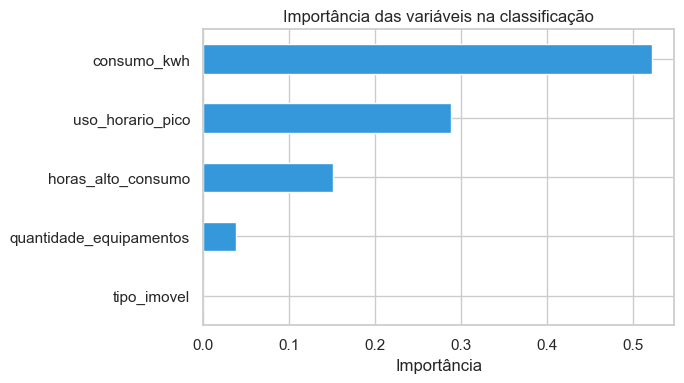

In [32]:
fig, ax = plt.subplots(figsize=(7, 4))
importance_df["importancia"].plot(kind="barh", ax=ax, color="#3498db")
ax.set_title("Importância das variáveis na classificação")
ax.set_xlabel("Importância")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Calibração das probabilidades (modelo final)

Árvores de decisão tendem a gerar probabilidades extremas (0.0 ou 1.0),
pois a confiança é calculada apenas pela pureza da folha onde a amostra
caiu. Para retornar uma probabilidade mais realista na API, aplicamos
`CalibratedClassifierCV`, que ajusta a saída de probabilidade usando
validação cruzada, sem alterar a lógica de decisão da árvore.

Este é o modelo que será de fato serializado e usado em produção (Parte 6).

In [33]:
arvore_calibrada = DecisionTreeClassifier(
    max_depth=6,
    random_state=RANDOM_STATE,
    class_weight="balanced",
)

modelo_calibrado = CalibratedClassifierCV(
    estimator=arvore_calibrada,
    method="sigmoid",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
)

pipeline_final = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", modelo_calibrado),
])

pipeline_final.fit(X_train, y_train)

y_pred_final = pipeline_final.predict(X_test)
print("Relatório de classificação (modelo final, calibrado):\n")
print(classification_report(y_test, y_pred_final))

Relatório de classificação (modelo final, calibrado):

              precision    recall  f1-score   support

   Eficiente       0.90      0.97      0.93        29
 Ineficiente       0.90      0.93      0.92        29
    Moderado       0.91      0.84      0.88        38

    accuracy                           0.91        96
   macro avg       0.91      0.91      0.91        96
weighted avg       0.91      0.91      0.91        96



In [34]:
exemplo = X_test.iloc[[0]]

proba_nao_calibrada = pipeline_base.predict_proba(exemplo)[0]
proba_calibrada = pipeline_final.predict_proba(exemplo)[0]
classes = pipeline_base.named_steps["classifier"].classes_

comparacao_proba = pd.DataFrame({
    "Classe": classes,
    "Sem calibração": proba_nao_calibrada.round(3),
    "Com calibração": proba_calibrada.round(3),
})
comparacao_proba

,Classe,Sem calibração,Com calibração
0,Eficiente,0.0,0.065
1,Ineficiente,1.0,0.625
2,Moderado,0.0,0.310


### Visualização da Árvore de Decisão

A principal vantagem de usar uma Árvore de Decisão é poder visualizar
exatamente as regras que o modelo aprendeu. Abaixo mostramos os **3
primeiros níveis de decisão**, que revelam as regras mais importantes.

**Como ler a árvore:**
- Cada caixa mostra a regra de decisão, a proporção de amostras e a classe dominante
- Ramo **esquerdo** = condição verdadeira (sim)
- Ramo **direito** = condição falsa (não)
- Cores mais fortes = maior certeza na classificação

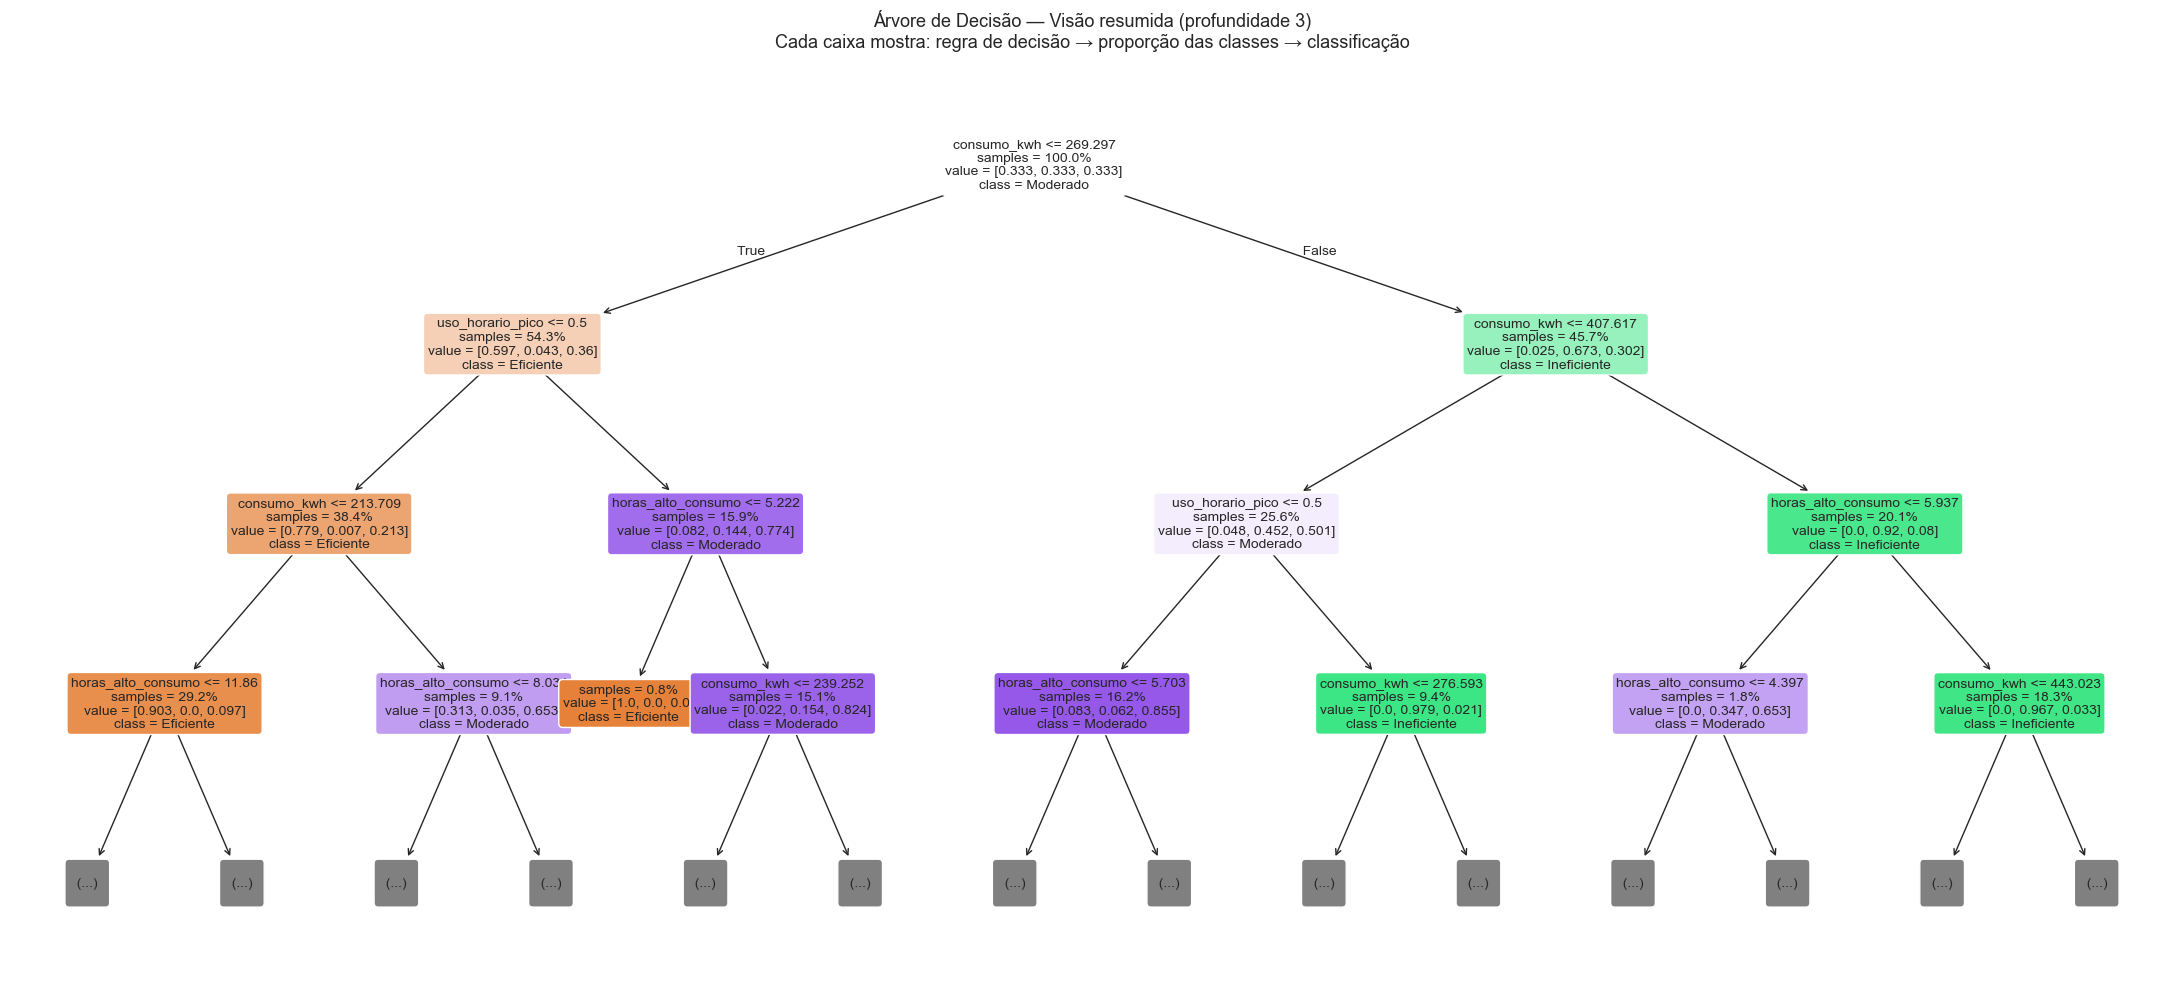

Imagem salva em: arvore_decisao\artifacts\arvore_decisao_resumida.png


In [35]:

# Recalcula os nomes das features de forma independente,
# garantindo que a célula funcione mesmo se executada isoladamente
feature_names_list = list(
    pipeline_base.named_steps["preprocessor"].get_feature_names_out()
)
classes_list = list(pipeline_base.named_steps["classifier"].classes_)

nomes_amigaveis = []
for name in feature_names_list:
    name_limpo = (
        name.replace("tipo_imovel_ohe__", "tipo_imovel=")
            .replace("remainder__", "")
    )
    nomes_amigaveis.append(name_limpo)

fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    pipeline_base.named_steps["classifier"],
    feature_names=nomes_amigaveis,
    class_names=classes_list,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=10,
    proportion=True,
    impurity=False,
    ax=ax,
)
ax.set_title(
    "Árvore de Decisão — Visão resumida (profundidade 3)\n"
    "Cada caixa mostra: regra de decisão → proporção das classes → classificação",
    fontsize=13,
    pad=20,
)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "arvore_decisao_resumida.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Imagem salva em: {ARTIFACTS_DIR / 'arvore_decisao_resumida.png'}")

## Parte 5 — Lógica de geração de recomendações

As recomendações não são frases fixas por categoria — são geradas
dinamicamente, correlacionando múltiplas variáveis da entrada com
**benchmarks estatísticos** calculados a partir da própria base de dados, e
**priorizadas pela importância de cada variável** extraída na Parte 8.

Regras implementadas:

| Regra | Variáveis correlacionadas | O que identifica |
|---|---|---|
| Concentração no horário de pico | `uso_horario_pico` + `horas_alto_consumo` | Uso intenso concentrado em horário caro |
| Consumo por equipamento elevado | `consumo_kwh` + `quantidade_equipamentos` + `tipo_imovel` | Possíveis equipamentos ineficientes |
| Muitos equipamentos, consumo controlado | `quantidade_equipamentos` + `consumo_kwh` | Alerta de standby, mesmo com bom desempenho geral |
| Consumo acima da média do tipo de imóvel | `consumo_kwh` + `tipo_imovel` | Comparação direta com pares semelhantes |
| Caso fronteiriço | `categoria` + `probabilidade` | Identifica quando o usuário está próximo de mudar de categoria |

Essa lógica está implementada em `models/arvore_decisao/recommendations.py`,
e os benchmarks utilizados são calculados abaixo.

In [36]:
df_bench = df.copy()
df_bench["consumo_por_equipamento"] = (
    df_bench["consumo_kwh"] / df_bench["quantidade_equipamentos"].replace(0, 1)
)

benchmarks = {
    "consumo_kwh": {
        "geral": {
            "p25": float(df_bench["consumo_kwh"].quantile(0.25)),
            "p50": float(df_bench["consumo_kwh"].quantile(0.50)),
            "p75": float(df_bench["consumo_kwh"].quantile(0.75)),
        },
        "por_tipo_imovel": df_bench.groupby("tipo_imovel")["consumo_kwh"].mean().round(2).to_dict(),
    },
    "consumo_por_equipamento": {
        "geral": {
            "p25": float(df_bench["consumo_por_equipamento"].quantile(0.25)),
            "p50": float(df_bench["consumo_por_equipamento"].quantile(0.50)),
            "p75": float(df_bench["consumo_por_equipamento"].quantile(0.75)),
        },
        "por_tipo_imovel": df_bench.groupby("tipo_imovel")["consumo_por_equipamento"].mean().round(2).to_dict(),
    },
    "horas_alto_consumo": {
        "p50": float(df_bench["horas_alto_consumo"].quantile(0.50)),
        "p75": float(df_bench["horas_alto_consumo"].quantile(0.75)),
    },
    "quantidade_equipamentos": {
        "p50": float(df_bench["quantidade_equipamentos"].quantile(0.50)),
        "p75": float(df_bench["quantidade_equipamentos"].quantile(0.75)),
    },
}

print(json.dumps(benchmarks, indent=2, ensure_ascii=False))

{
  "consumo_kwh": {
    "geral": {
      "p25": 165.27449995,
      "p50": 244.821,
      "p75": 364.285500125
    },
    "por_tipo_imovel": {
      "APARTAMENTO": 179.99,
      "CASA": 347.41,
      "COMERCIO": 644.87
    }
  },
  "consumo_por_equipamento": {
    "geral": {
      "p25": 26.15356249375,
      "p50": 32.25006254375,
      "p75": 39.60821428928572
    },
    "por_tipo_imovel": {
      "APARTAMENTO": 31.17,
      "CASA": 38.41,
      "COMERCIO": 41.77
    }
  },
  "horas_alto_consumo": {
    "p50": 7.937956204379562,
    "p75": 9.02227881956966
  },
  "quantidade_equipamentos": {
    "p50": 7.0,
    "p75": 11.0
  }
}


## Parte 06 — Serialização do modelo e do contexto de recomendação

Os dois artefatos abaixo são exatamente os consumidos pelo microsserviço
Python (`models/arvore_decisao/`):

- `decision_tree_model.joblib` — pipeline completo (pré-processamento +
  modelo calibrado);
- `recommendation_context.json` — importância de variáveis e benchmarks,
  usados pela lógica de geração de recomendações (`recommendations.py`).

In [37]:
MODEL_PATH = ARTIFACTS_DIR / "decision_tree_model.joblib"
CONTEXT_PATH = ARTIFACTS_DIR / "recommendation_context.json"

joblib.dump(pipeline_final, MODEL_PATH)

context = {
    "feature_importances": importance_by_variable,
    "benchmarks": benchmarks,
}
with open(CONTEXT_PATH, "w", encoding="utf-8") as f:
    json.dump(context, f, ensure_ascii=False, indent=2)

print(f"Modelo salvo em: {MODEL_PATH}")
print(f"Contexto de recomendação salvo em: {CONTEXT_PATH}")

Modelo salvo em: arvore_decisao\artifacts\decision_tree_model.joblib
Contexto de recomendação salvo em: arvore_decisao\artifacts\recommendation_context.json


## Parte 07 — Exemplos de utilização do modelo

Testamos o pipeline final com casos simulados, representando diferentes
perfis de consumo — o mesmo conjunto de exemplos documentado como
evidência de funcionamento da API (`POST /predict`).

In [38]:
exemplos = pd.DataFrame([
    {  # Exemplo 1: consumo alto, horário de pico, casa
        "consumo_kwh": 420, "horas_alto_consumo": 8, "uso_horario_pico": 1,
        "tipo_imovel": "CASA", "quantidade_equipamentos": 10,
    },
    {  # Exemplo 2: consumo baixo, apartamento
        "consumo_kwh": 87, "horas_alto_consumo": 3, "uso_horario_pico": 0,
        "tipo_imovel": "APARTAMENTO", "quantidade_equipamentos": 4,
    },
    {  # Exemplo 3: consumo moderado, comércio
        "consumo_kwh": 260, "horas_alto_consumo": 5, "uso_horario_pico": 0,
        "tipo_imovel": "COMERCIO", "quantidade_equipamentos": 11,
    },
])

previsoes = pipeline_final.predict(exemplos)
probabilidades = pipeline_final.predict_proba(exemplos).max(axis=1)

resultado = exemplos.copy()
resultado["categoria_predita"] = previsoes
resultado["probabilidade"] = probabilidades.round(2)
resultado

,consumo_kwh,horas_alto_consumo,uso_horario_pico,tipo_imovel,quantidade_equipamentos,categoria_predita,probabilidade
0,420,8,1,CASA,10,Ineficiente,0.80
1,87,3,0,APARTAMENTO,4,Eficiente,0.80
2,260,5,0,COMERCIO,11,Eficiente,0.81
